# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

I DO HEREBY ACKNOWLEDGE THAT I USED CHATGPT FOR DEBUGGING CODES AND CONVERTING SOME OF THE R CODES INTO PYTHON CODES

In [4]:
# filter dplyr warnings
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(len(raw_data))

7214


In [7]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [9]:
import pandas as pd
import numpy as np

# Define variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

#  Filtering
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

#  Derived categorical variables with reference levels
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [r for r in df["race"].unique() if r != "Caucasian"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"].map({"Female": "Female", "Male": "Male"}),
    categories=["Male", "Female"]
)

df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = df["score_factor"].astype("category")

# Equivalent of nrow(df)
print(len(df))

6172


In [10]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [11]:
def glimpse(df, n=10):
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}\n")

    for col in df.columns:
        dtype = df[col].dtype
        values = ", ".join(map(str, df[col].head(n).tolist()))
        print(f"$ {col:<25} <{dtype}> {values}")

glimpse(df)

Rows: 6,172
Columns: 18

$ age                       <int64> 69, 34, 24, 44, 41, 43, 39, 27, 23, 37
$ c_charge_degree           <category> F, F, F, M, F, F, M, F, M, M
$ race                      <category> Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian
$ age_cat                   <category> Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45
$ score_text                <category> Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low
$ sex                       <category> Male, Male, Male, Male, Male, Male, Female, Male, Male, Female
$ priors_count              <int64> 0, 0, 4, 0, 14, 3, 0, 0, 3, 0
$ days_b_screening_arrest   <float64> -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0
$ decile_score              <int64> 1, 3, 4, 1, 6, 4, 1, 4, 6, 1
$ is_recid                  <category> 0, 1, 1, 0, 1, 0, 0, 0, 1, 0
$ two_year_recid            <category> 0

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [12]:
df["length_of_stay"] = (
    pd.to_datetime(df["c_jail_out"].astype(str).str[:10]) -
    pd.to_datetime(df["c_jail_in"].astype(str).str[:10])
).dt.days

df[["length_of_stay", "decile_score"]].corr().iloc[0, 1]

np.float64(0.20732969161470416)

After filtering we have the following demographic breakdown:

In [13]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [14]:
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [15]:
print("Black defendants: %.2f%%" % (3175 / 6172 * 100))
print("White defendants: %.2f%%" % (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" % (509 / 6172 * 100))
print("Asian defendants: %.2f%%" % (31 / 6172 * 100))
print("Native American defendants: %.2f%%" % (11 / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [16]:
counts = df["score_text"].value_counts()

print("High Low Medium")
print(counts["High"], counts["Low"], counts["Medium"])

High Low Medium
1144 3421 1607


In [17]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [18]:
print("Female Male")
counts = df["sex"].value_counts()
print(counts["Female"], counts["Male"])

Female Male
1175 4997


In [19]:
print("Men: %.2f%%" % (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [20]:
len(df[df["two_year_recid"] == 1])

2809

In [21]:
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

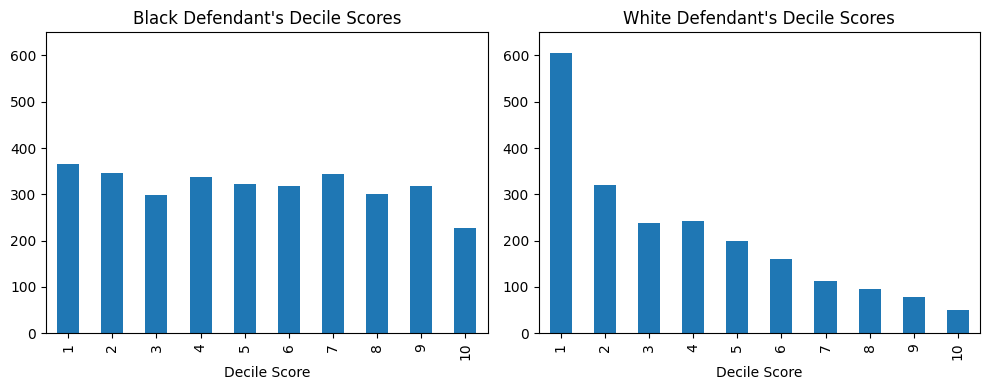

In [22]:
import matplotlib.pyplot as plt

# Filter data
black = df[df["race"] == "African-American"]
white = df[df["race"] == "Caucasian"]

# Create subplots (2 charts side by side)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Black defendants decile scores
black["decile_score"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_xlabel("Decile Score")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_ylim(0, 650)

# White defendants decile scores
white["decile_score"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_xlabel("Decile Score")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [24]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Re-create score_factor as numeric (0 or 1) directly from score_text
# 'HighScore' corresponds to 1, 'LowScore' corresponds to 0
df["score_factor"] = np.where(df["score_text"] != "Low", 1, 0).astype(int)

# Create dummy variables (equivalent to R factors)
X = pd.get_dummies(
    df[["gender_factor","age_factor","race_factor","priors_count","crime_factor","two_year_recid"]],
    drop_first=True
).astype(int)

# Add intercept
X = sm.add_constant(X)

# Target variable
y = df["score_factor"]

# Logistic regression model
model_glm = sm.Logit(y, X).fit()

# Print summary (equivalent to summary(model_glm) in R)
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        08:49:41   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.5255      0.079    -19.430      0.000

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [25]:
import math

control = math.exp(-1.52554) / (1 + math.exp(-1.52554))

result = math.exp(0.47721) / (1 - control + (control * math.exp(0.47721)))

print(f"{result:.7g}")

1.452841


Women are 19.4% more likely than men to get a higher score.

In [26]:
import math

result = math.exp(0.22127) / (1 - control + (control * math.exp(0.22127)))

print(f"{result:.7g}")

1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [27]:
import math

result = math.exp(1.30839) / (1 - control + (control * math.exp(1.30839)))

print(f"{result:.7g}")

2.49612


In [28]:
# Predicted probabilities from logistic model
df["pred_prob"] = model_glm.predict(X)

# Predicted class (threshold = 0.5)
df["pred_class"] = df["pred_prob"].apply(lambda x: "Recid" if x >= 0.5 else "No Recid")


In [29]:
import pandas as pd

print("\n— Overall Confusion Matrix —")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


— Overall Confusion Matrix —
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [30]:
import pandas as pd

print("\n— Confusion Matrix by Race —")

# Create actual and predicted variables
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

def compute_metrics(group):
    TP = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    TN = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    FP = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    FN = ((group["pred"] == 0) & (group["actual"] == 1)).sum()

    n = len(group)

    accuracy  = round((TP + TN) / n, 3)
    precision = round(TP / (TP + FP) if (TP + FP) > 0 else 0, 3)
    recall    = round(TP / (TP + FN) if (TP + FN) > 0 else 0, 3)
    fpr       = round(FP / (FP + TN) if (FP + TN) > 0 else 0, 3)
    fnr       = round(FN / (FN + TP) if (FN + TP) > 0 else 0, 3)

    return pd.Series({
        "n": n,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "FPR": fpr,
        "FNR": fnr
    })

race_metrics = (
    df.groupby("race")
      .apply(compute_metrics)
      .sort_values("n", ascending=False)
)

print(race_metrics)


— Confusion Matrix by Race —
                       n      TP      TN     FP     FN  Accuracy  Precision  \
race                                                                          
African-American  3175.0  1373.0   959.0  555.0  288.0     0.734      0.712   
Caucasian         2103.0   381.0  1148.0  133.0  441.0     0.727      0.741   
Hispanic           509.0    81.0   306.0   14.0  108.0     0.760      0.853   
Other              343.0    22.0   216.0    3.0  102.0     0.694      0.880   
Asian               31.0     2.0    22.0    1.0    6.0     0.774      0.667   
Native American     11.0     5.0     2.0    4.0    0.0     0.636      0.556   

                  Recall    FPR    FNR  
race                                    
African-American   0.827  0.367  0.173  
Caucasian          0.464  0.104  0.536  
Hispanic           0.429  0.044  0.571  
Other              0.177  0.014  0.823  
Asian              0.250  0.043  0.750  
Native American    1.000  0.667  0.000  


In [31]:
print("\n— FPR and FNR Disparity by Race —")

# Select required columns
disparity = race_metrics[["n", "FPR", "FNR"]].copy()
disparity["race"] = disparity.index

# Get Caucasian reference values
caucasian_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

# Reorder columns to match R output
disparity = disparity[["race", "n", "FPR", "FNR", "delta_FPR", "delta_FNR"]]

print(disparity)


— FPR and FNR Disparity by Race —
                              race       n    FPR    FNR  delta_FPR  delta_FNR
race                                                                          
African-American  African-American  3175.0  0.367  0.173      0.263     -0.363
Caucasian                Caucasian  2103.0  0.104  0.536      0.000      0.000
Hispanic                  Hispanic   509.0  0.044  0.571     -0.060      0.035
Other                        Other   343.0  0.014  0.823     -0.090      0.287
Asian                        Asian    31.0  0.043  0.750     -0.061      0.214
Native American    Native American    11.0  0.667  0.000      0.563     -0.536


# LECTURE 2 LIVE CODING

In [36]:
from sklearn.model_selection import train_test_split

# Define features and target based on the logistic regression model
features = ["gender_factor", "age_factor", "race_factor", "priors_count", "crime_factor"]
target = "two_year_recid"

# Prepare X and y for train_test_split (remove get_dummies here)
X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 5), Test: (1235, 5)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features based on the 'features' list from previous cells
numeric_features = ["priors_count"]
category_features = ["gender_factor", "age_factor", "race_factor", "crime_factor"]

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
    ]
)

# Logistic regression (GLM-- interpretable by design)
lr_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
    ]
)
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [41]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    # Add the 'race' column from the original df using the index
    if group_col == "race" and "race" not in X_.columns:
        # Ensure the 'df' DataFrame is accessible (it's in the global scope here)
        X_["race"] = df.loc[X_.index, "race"]

    for group, gdf in X_.groupby(group_col):
        # Ensure confusion matrix always returns a 2x2 array by specifying labels
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()
        results.append({
            "race" : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn) if (fp + tn) > 0 else 0, 3),
            "FNR" : round(fn / (fn + tp) if (fn + tp) > 0 else 0, 3),
            "AUC" : round(roc_auc_score(
                gdf["actual"],
                gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.694  0.326  0.288  0.752
2         Caucasian  427     0.663  0.158  0.634  0.669
3          Hispanic   94     0.606  0.082  0.733  0.629
5             Other   65     0.769  0.106  0.556  0.755
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000  0.000    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.688  0.276  0.344  0.728
2         Caucasian  427     0.660  0.165  0.627  0.684
3          Hispanic   94     0.660  0.204  0.489  0.621
5             Other   65     0.754  0.128  0.556  0.778
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000  0.000    NaN


In [48]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
training_data = X_train_enc,
feature_names = (numeric_features +
list(preprocessor
     .named_transformers_["cat"]
.get_feature_names_out(
category_features))),
class_names = ["No Recid", "Recid"],
mode = "classification",
discretize_continuous= True,
random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Filter for African-American defendants and select the middle index
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
black_idx = black_df.index[len(black_df) // 2]

# Filter for Caucasian defendants and select the middle index
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")
white_idx = white_df.index[len(white_df) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
    data_row = row_enc[0],
    predict_fn= gbt_pipeline["classifier"].predict_proba,
    num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
    f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.487
 age_factor_Less than 25 > 0.00           +0.1941
 age_factor_Greater than 45 <= 0.00       +0.0966
 age_factor_25 - 45 <= 0.00               -0.0449
 crime_factor_F <= 0.00                   -0.0357
 0.00 < crime_factor_M <= 1.00            -0.0207
 0.00 < race_factor_African-American <= 1.00 +0.0190

 LIME: White defendant 
Predicted probability: 0.348
 age_factor_Less than 25 <= 0.00          -0.1932
 race_factor_Asian <= 0.00                +0.1616
 age_factor_Greater than 45 <= 0.00       +0.0954
 -0.48 < priors_count <= 0.16             -0.0617
 0.00 < age_factor_25 - 45 <= 1.00        +0.0419
 crime_factor_F <= 0.00                   -0.0391


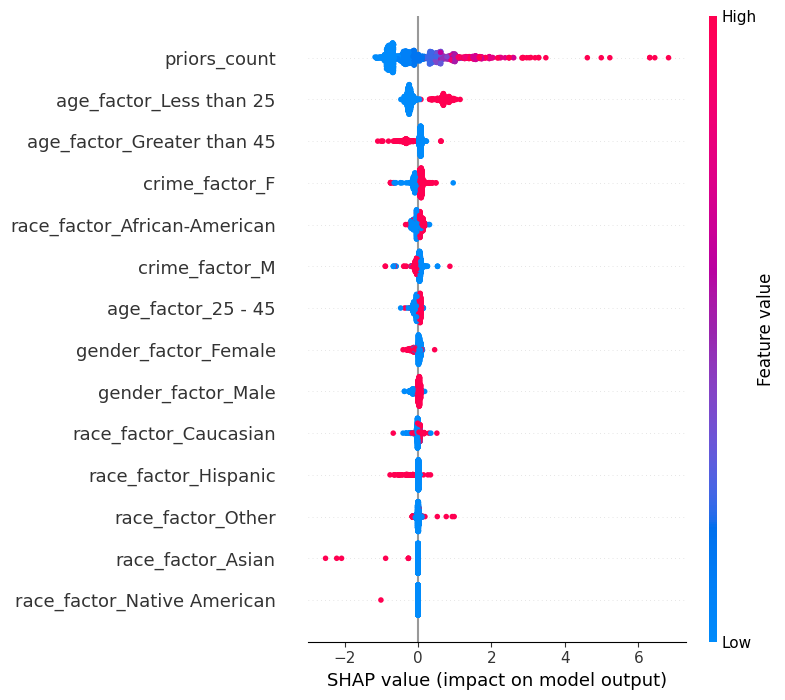

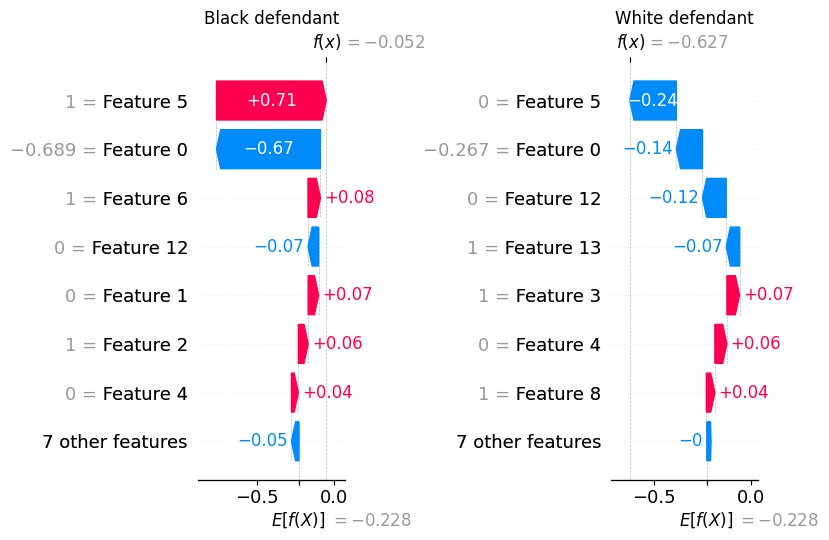

In [50]:
# !pip install shap
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (
numeric_features +
list(preprocessor
.named_transformers_["cat"]
.get_feature_names_out(
category_features)))
explainer_shap = shap.Explainer(
gbt_pipeline["classifier"],
shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
feature_names=feat_names)
# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
(axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
    max_display=8,
    show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

In [54]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
import pandas as pd

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
dataframe = pd.concat([X_train, y_train], axis=1),
continuous_features = numeric_features,
outcome_name = target
)
dice_model = dice_ml.Model(
model = gbt_pipeline,
backend = "sklearn",
model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"priors_count": [0, 38],
    "age_factor": ["Less than 25", "25 - 45", "Greater than 45"],
    "crime_factor": ["F", "M"]},
    features_to_vary = ["age_factor", "priors_count",
    "crime_factor"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.90it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,Less than 25,African-American,0,M,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,-,-,-,31,-,1
1,-,-,-,9,F,1
2,-,-,-,16,-,1


100%|██████████| 1/1 [00:00<00:00,  7.95it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,25 - 45,Caucasian,2,M,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,-,-,-,19,F,1
1,-,Less than 25,-,-,-,1
2,-,Greater than 45,-,9,-,1


## INDIVIDUAL ASSIGNMENT 2


--- SHAP Beeswarm Summary Plot ---


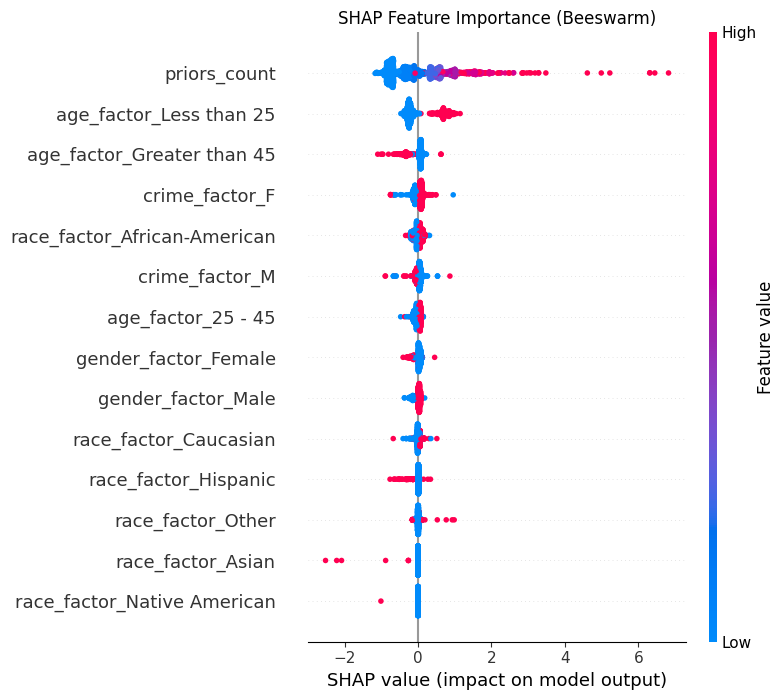


--- SHAP Waterfall Plots for Highest/Lowest Risk per Race ---


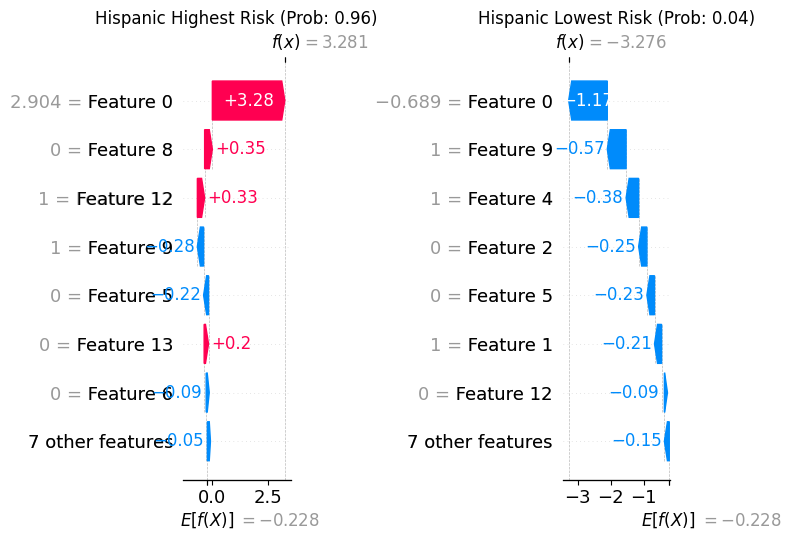

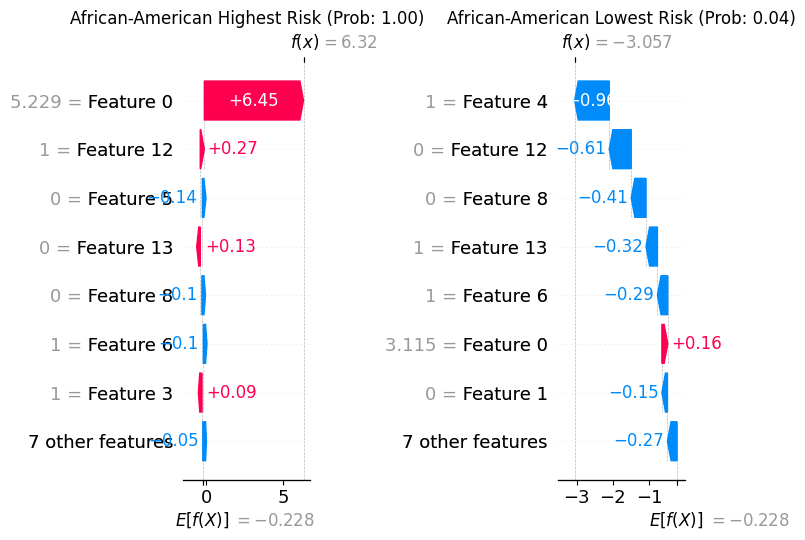

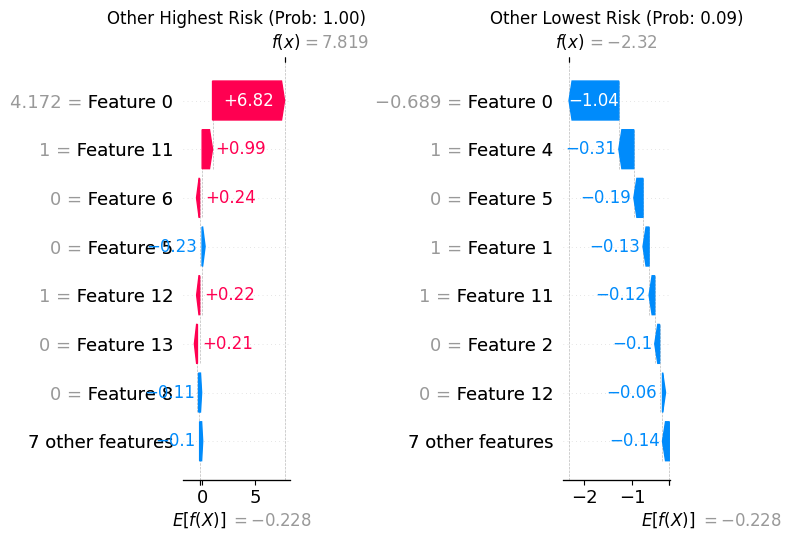

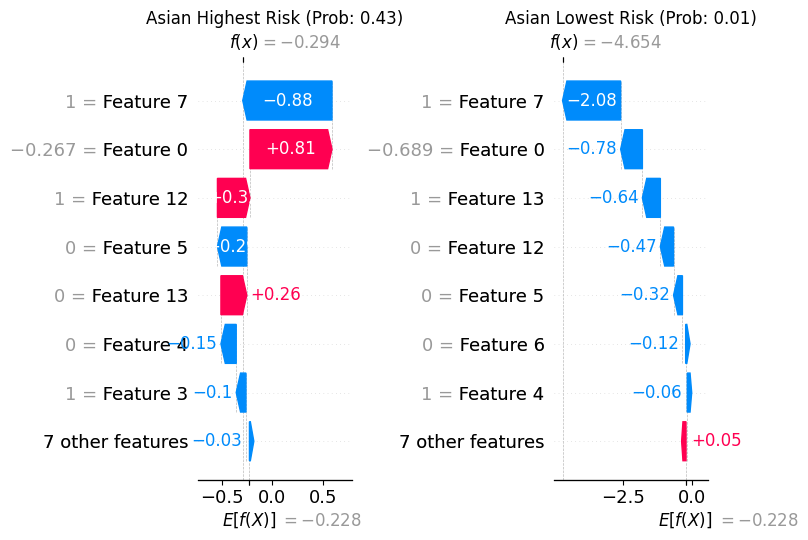

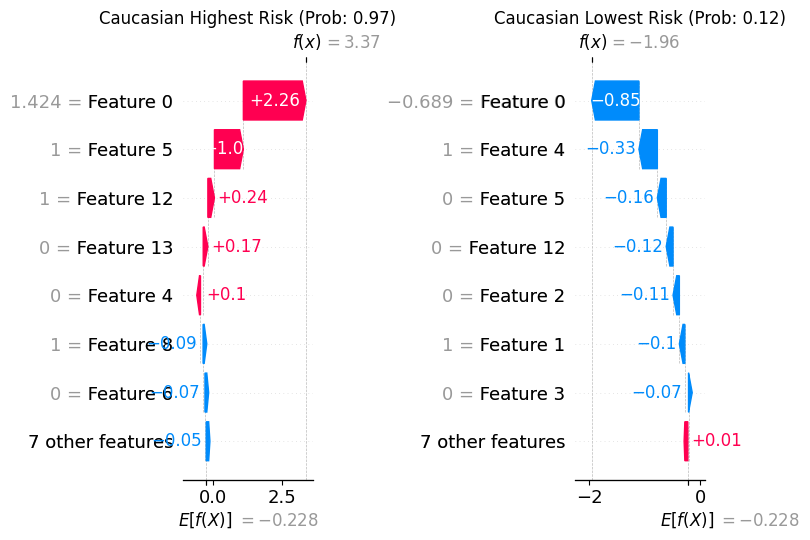

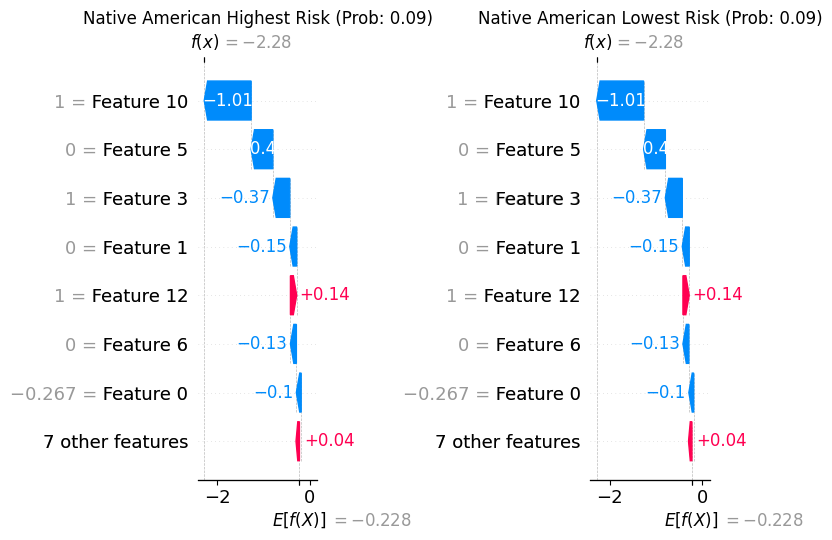

In [56]:
import shap
import matplotlib.pyplot as plt

# Ensure X_test_enc and feat_names are available from previous cells
X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor
         .named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

# Initialize SHAP Explainer (using the already fitted GBT model)
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc)

# (a) Global beeswarm summary plot
print("\n--- SHAP Beeswarm Summary Plot ---")
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names, show=False)
plt.title("SHAP Feature Importance (Beeswarm)")
plt.tight_layout()
plt.show()

# (b) Waterfall plots for highest-risk and lowest-risk defendant in each racial group
print("\n--- SHAP Waterfall Plots for Highest/Lowest Risk per Race ---")
unique_races = X_test_copy["race_factor"].unique()

for race in unique_races:
    race_df = X_test_copy[X_test_copy["race_factor"] == race]

    # Skip if racial group is empty
    if len(race_df) == 0:
        continue

    # Get original DataFrame index for highest and lowest risk within this racial group
    highest_risk_idx_orig = race_df["pred_prob"].idxmax()
    lowest_risk_idx_orig = race_df["pred_prob"].idxmin()

    # Convert original DataFrame index to position in X_test (for shap_values array)
    highest_risk_loc = X_test.index.get_loc(highest_risk_idx_orig)
    lowest_risk_loc = X_test.index.get_loc(lowest_risk_idx_orig)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Two subplots for comparison

    # Plot for Highest Risk Defendant
    plt.sca(axes[0]) # Set current axes
    shap.waterfall_plot(shap_values[highest_risk_loc], max_display=8, show=False)
    axes[0].set_title(f"{race} Highest Risk (Prob: {race_df.loc[highest_risk_idx_orig, 'pred_prob']:.2f})")

    # Plot for Lowest Risk Defendant
    plt.sca(axes[1]) # Set current axes
    shap.waterfall_plot(shap_values[lowest_risk_loc], max_display=8, show=False)
    axes[1].set_title(f"{race} Lowest Risk (Prob: {race_df.loc[lowest_risk_idx_orig, 'pred_prob']:.2f})")

    plt.tight_layout()
    plt.show()

### Explanation of SHAP Plots

SHAP plots help explain how features influence the model’s predictions. The SHAP beeswarm summary plot shows overall feature importance across the dataset, where features on the y-axis are ranked by importance, the x-axis shows the SHAP value (how much a feature increases or decreases the prediction), and colors represent feature values (red = high, blue = low). Features farther from zero have a stronger effect on predicting recidivism, with variables like priors_count and age_factor_Less than 25 often increasing predicted risk. The SHAP waterfall plots explain individual predictions by showing how each feature moves the prediction from the average model prediction (expected value) to the final prediction for that individual, with positive contributions increasing risk and negative contributions decreasing it, helping reveal why a specific person was classified as high or low risk.

In [61]:
import lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

# Re-initialize explainer for clarity, though it's already in memory
X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (
        numeric_features +
        list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
    ),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous = True,
    random_state = 42
)

# Ensure X_test_copy is up-to-date with predicted probabilities
# It was created in a previous cell but let's re-create it to be safe.
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Filter for African-American defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"]
# Filter for Caucasian defendants
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"]

# Get original DataFrame indices for highest and lowest risk within each racial group
black_highest_risk_idx_orig = black_df["pred_prob"].idxmax() if not black_df.empty else None
black_lowest_risk_idx_orig = black_df["pred_prob"].idxmin() if not black_df.empty else None
white_highest_risk_idx_orig = white_df["pred_prob"].idxmax() if not white_df.empty else None
white_lowest_risk_idx_orig = white_df["pred_prob"].idxmin() if not white_df.empty else None

# Generate and display LIME explanations for each selected individual
individuals_to_explain = [
    (black_highest_risk_idx_orig, "African-American Highest Risk"),
    (black_lowest_risk_idx_orig, "African-American Lowest Risk"),
    (white_highest_risk_idx_orig, "Caucasian Highest Risk"),
    (white_lowest_risk_idx_orig, "Caucasian Lowest Risk")
]

for idx_orig, label in individuals_to_explain:
    if idx_orig is not None:
        # Get the row from X_test using the original index
        query_instance = X_test.loc[[idx_orig]]

        # Transform the query instance using the preprocessor
        row_enc = preprocessor.transform(query_instance)

        # Get predicted probability for this instance
        predicted_prob = X_test_copy.loc[idx_orig, "pred_prob"]

        # Generate LIME explanation
        exp = explainer.explain_instance(
            data_row = row_enc[0], # LIME expects a single 1D array
            predict_fn = gbt_pipeline["classifier"].predict_proba, # Use the classifier from the pipeline
            num_features = 6
        )

        print(f"\n --- LIME Explanation: {label} ---")
        print(f"Predicted probability: {predicted_prob:.3f}")
        for feat, weight in exp.as_list():
            print(f"  {feat:<40} {weight:+.4f}")
    else:
        print(f"\n --- LIME Explanation: {label} ---")
        print(f"  No data available for this category to determine highest/lowest risk.")


 --- LIME Explanation: African-American Highest Risk ---
Predicted probability: 0.998
  priors_count > 0.16                      +0.2420
  age_factor_Less than 25 <= 0.00          -0.1953
  age_factor_Greater than 45 <= 0.00       +0.0977
  0.00 < age_factor_25 - 45 <= 1.00        +0.0410
  0.00 < crime_factor_F <= 1.00            +0.0367
  crime_factor_M <= 0.00                   +0.0211

 --- LIME Explanation: African-American Lowest Risk ---
Predicted probability: 0.045
  priors_count > 0.16                      +0.2482
  age_factor_Less than 25 <= 0.00          -0.1927
  race_factor_Asian <= 0.00                +0.1728
  age_factor_Greater than 45 > 0.00        -0.0990
  age_factor_25 - 45 <= 0.00               -0.0412
  crime_factor_F <= 0.00                   -0.0409

 --- LIME Explanation: Caucasian Highest Risk ---
Predicted probability: 0.967
  priors_count > 0.16                      +0.2434
  age_factor_Less than 25 > 0.00           +0.1834
  age_factor_Greater than 45 <= 0

### Comparison of LIME and SHAP Feature Attributions and Implications for Governance

LIME and SHAP often agree on the direction and key features influencing predictions, such as priors_count and age factors increasing recidivism risk. However, they can differ in magnitude and detail because LIME uses a local linear approximation while SHAP uses a game-theoretic approach that better captures feature interactions. These differences mean explanations may vary for the same prediction. For governance, this highlights the importance of using multiple interpretability methods to ensure transparency, detect potential bias, and verify that model explanations are reliable in high-stakes decisions like criminal justice risk assessments.

In [62]:
import dice_ml
from dice_ml import Dice
import pandas as pd

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)
dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")

# Ensure X_test_copy is up-to-date with predicted probabilities
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Filter for African-American defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"]
# Filter for Caucasian defendants
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"]

# Get original DataFrame indices for highest and lowest risk within each racial group
black_highest_risk_idx_orig = black_df["pred_prob"].idxmax() if not black_df.empty else None
black_lowest_risk_idx_orig = black_df["pred_prob"].idxmin() if not black_df.empty else None
white_highest_risk_idx_orig = white_df["pred_prob"].idxmax() if not white_df.empty else None
white_lowest_risk_idx_orig = white_df["pred_prob"].idxmin() if not white_df.empty else None

# Generate and display DiCE counterfactuals for each selected individual
individuals_to_explain = [
    (black_highest_risk_idx_orig, "African-American Highest Risk"),
    (black_lowest_risk_idx_orig, "African-American Lowest Risk"),
    (white_highest_risk_idx_orig, "Caucasian Highest Risk"),
    (white_lowest_risk_idx_orig, "Caucasian Lowest Risk")
]

print("\n--- DiCE Counterfactuals ---")
for idx_orig, label in individuals_to_explain:
    if idx_orig is not None:
        query_instance = X_test.loc[[idx_orig]]
        cf = exp_dice.generate_counterfactuals(
            query_instance,
            total_CFs = 1, # Get at least one counterfactual
            desired_class = "opposite",
            permitted_range = {
                "priors_count": [0, 38], # Max from original dataset
                "age_factor": ["Less than 25", "25 - 45", "Greater than 45"],
                "crime_factor": ["F", "M"]
            },
            features_to_vary = ["age_factor", "priors_count", "crime_factor"]
        )
        print(f"\nDiCE counterfactuals: {label}")
        cf.visualize_as_dataframe(show_only_changes=True)
    else:
        print(f"\nDiCE counterfactuals: {label}")
        print(f"  No data available for this category.")



--- DiCE Counterfactuals ---


100%|██████████| 1/1 [00:00<00:00,  5.93it/s]


DiCE counterfactuals: African-American Highest Risk
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,25 - 45,African-American,28,F,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  9.53it/s]


DiCE counterfactuals: Caucasian Lowest Risk
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Female,Greater than 45,Caucasian,0,M,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,-,-,-,23,-,1


### DiCE Counterfactual Summary

DiCE generates counterfactuals, showing minimal feature changes needed to flip a prediction. Features varied include `age_factor`, `priors_count`, and `crime_factor`. Since `race` and `sex` were not specified in `features_to_vary`, counterfactuals do not require changes to these immutable demographic attributes. This demonstrates how altering mutable factors can change predicted risk, aligning with ethical considerations in fairness.